<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [ ]:
!pip install pandas

In [ ]:
!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [1]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-09-08 03:18:50--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  47.8MB/s    in 3.6s    

2026-09-08 03:18:54 (42.0 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [2]:
##Write your code here
# Ordered age categories
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older',
    'Prefer not to say'
]

def order_age(df, col='Age'):
    "Convert Age column into ordered categorical variables"
    df[col] = pd.Categorical(df[col], categories=age_order, ordered=True)
    return df

def explode_multiselect(df, column, separator=';'):
    'Multi select explode function'
    df_clean = df.copy()
    df_clean = df_clean.dropna(subset=[column])
    df_clean[column] = df_clean[column].str.split(separator)
    df_clean = df_clean.explode(column)
    df_clean[column] = df_clean[column].str.strip()
    return df_clean

def clean_comp(df, col='ConvertedCompYearly'):
    'Remove extreme outliers from comp using the IQR'
    df_clean = df.copy()
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + (1.5 * iqr)
    df_clean = df_clean[df_clean[col] <= upper]
    return df_clean

def median_by_age(df, cols):
    'compute median values by ordered age groups'
    temp = df.groupby('Age')[cols].median()
    temp = temp.loc[age_order] # for correct visual order
    return temp

df_clean = df.copy()
# clean compensation
comp= df_clean['ConvertedCompYearly']
comp = pd.to_numeric(comp, errors='coerce')
df_clean = df_clean[df_clean['ConvertedCompYearly'].isin(comp)]

#clean Age
df_clean = df_clean[df_clean['Age'].isin(age_order)]
#order categories properly
age_type = pd.CategoricalDtype(categories=age_order, ordered=True)
df_clean['Age'] = df_clean['Age'].astype(age_type)

# Clean Experience
df_clean['WorkExp'] = pd.to_numeric(df_clean['WorkExp'], errors='coerce')

# Drop extreme work exp values
df_clean = df_clean[(df_clean['WorkExp'] >= 0) & (df_clean['WorkExp'] <= 60)]

# Clean Job Sat
df_clean['JobSat'] = pd.to_numeric(df_clean['JobSat'], errors='coerce')

# clean Job Sat 6
df_clean['JobSatPoints_6'] = pd.to_numeric(df_clean['JobSatPoints_6'], errors='coerce')


df1 = order_age(df.copy())
df_comp = clean_comp(df1)
test = median_by_age(df_comp, ['JobSatPoints_6', 'JobSatPoints_7', 'JobSat'])
test

/var/folders/0l/pvtw36_j26v20v1h4xc53l940000gn/T/ipykernel_85773/4219272451.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df.groupby('Age')[cols].median()


,JobSatPoints_6,JobSatPoints_7,JobSat
Age,,,
Under 18 years old,10.0,5.0,8.0
18-24 years old,20.0,20.0,7.0
25-34 years old,20.0,15.0,7.0
35-44 years old,20.0,15.0,7.0
45-54 years old,20.0,15.0,7.0
55-64 years old,20.0,20.0,8.0
65 years or older,22.5,15.0,8.0
Prefer not to say,10.0,20.0,8.0


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



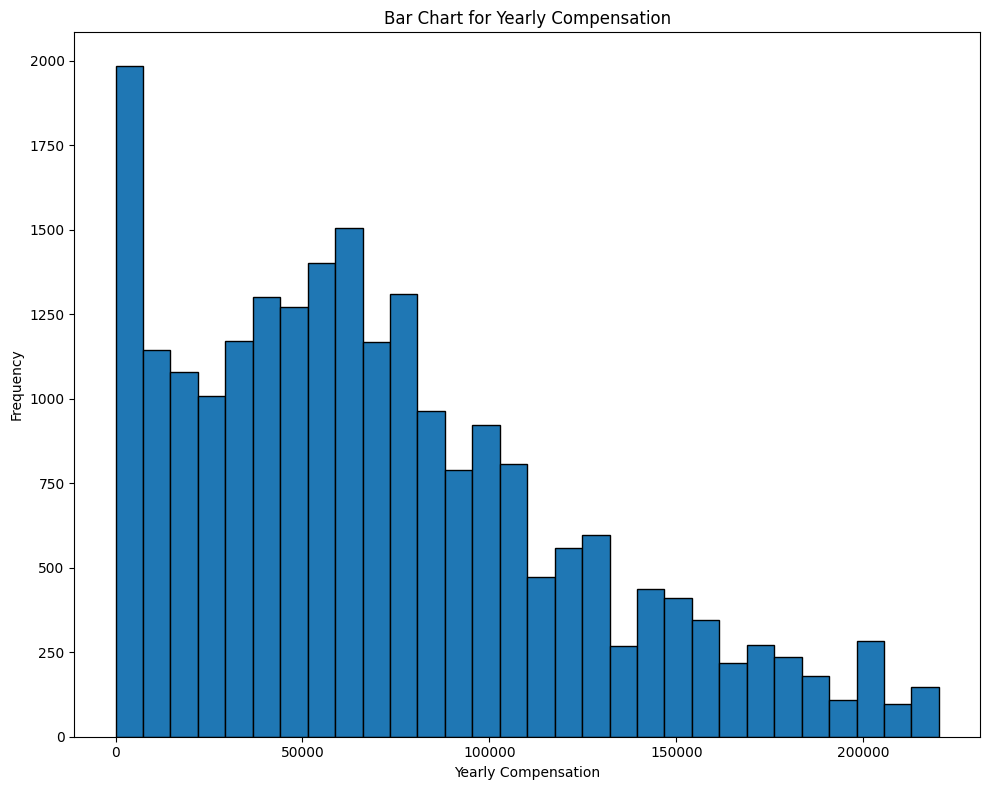

In [3]:
## Write your code here
df_clean_comp = clean_comp((df.copy()))

plt.figure(figsize=(10, 8))

df_clean_comp['ConvertedCompYearly'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('Bar Chart for Yearly Compensation')
plt.xlabel('Yearly Compensation')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



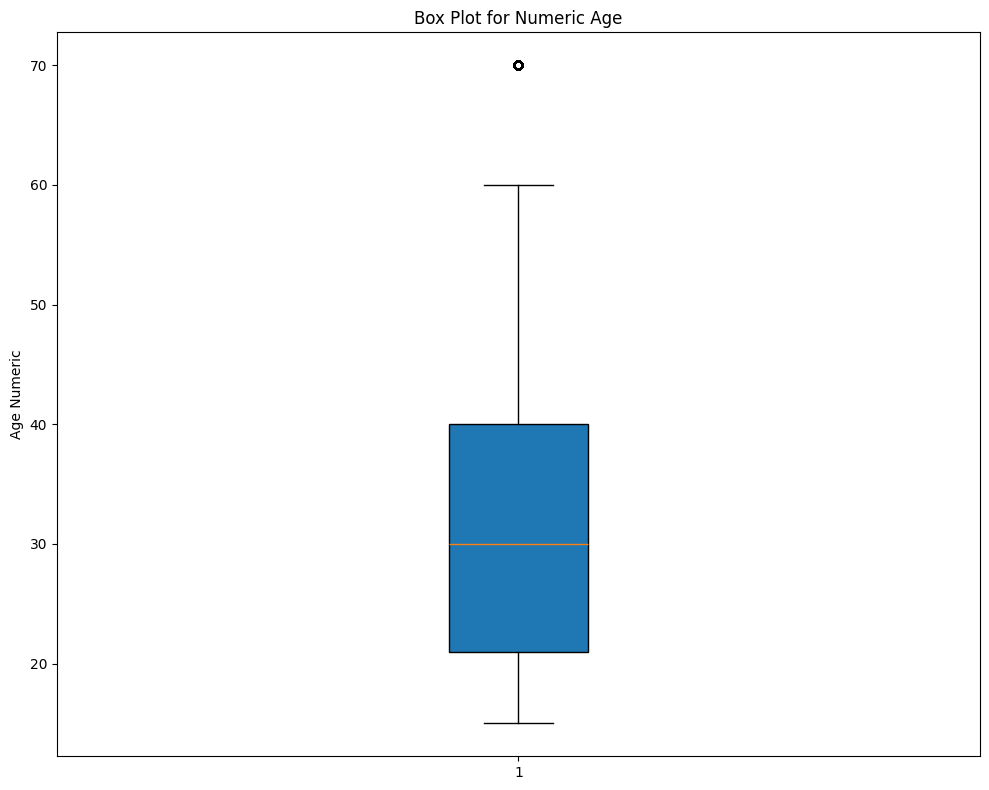

In [4]:
## Write your code here
age_map = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

plt.figure(figsize=(10, 8))

df['Age_numeric'] = df['Age'].map(age_map)

plt.boxplot(df['Age_numeric'].dropna(), vert=True, patch_artist=True)
plt.title('Box Plot for Numeric Age')
plt.ylabel('Age Numeric')
plt.tight_layout()
plt.show()

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



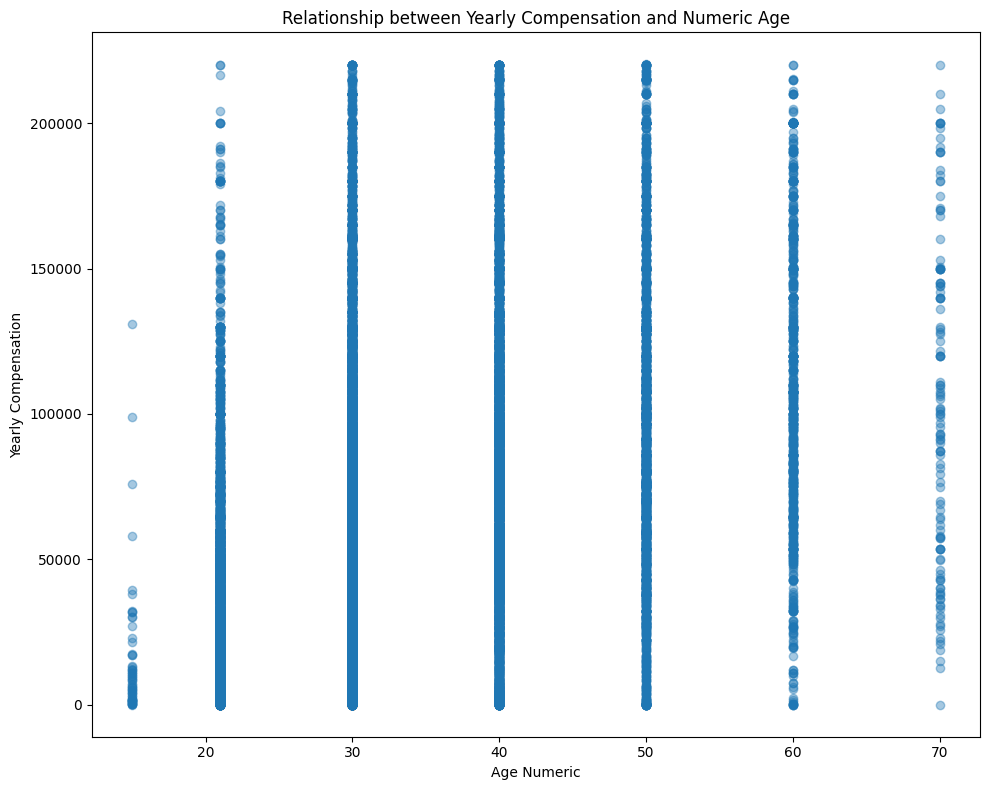

In [5]:
## Write your code here
df_CC_A = clean_comp(df[['Age_numeric', 'ConvertedCompYearly']])

plt.figure(figsize=(10, 8))

plt.scatter(df_CC_A['Age_numeric'], df_CC_A['ConvertedCompYearly'], alpha=0.4)

plt.title('Relationship between Yearly Compensation and Numeric Age')
plt.xlabel('Age Numeric')
plt.ylabel('Yearly Compensation')
plt.tight_layout()
plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


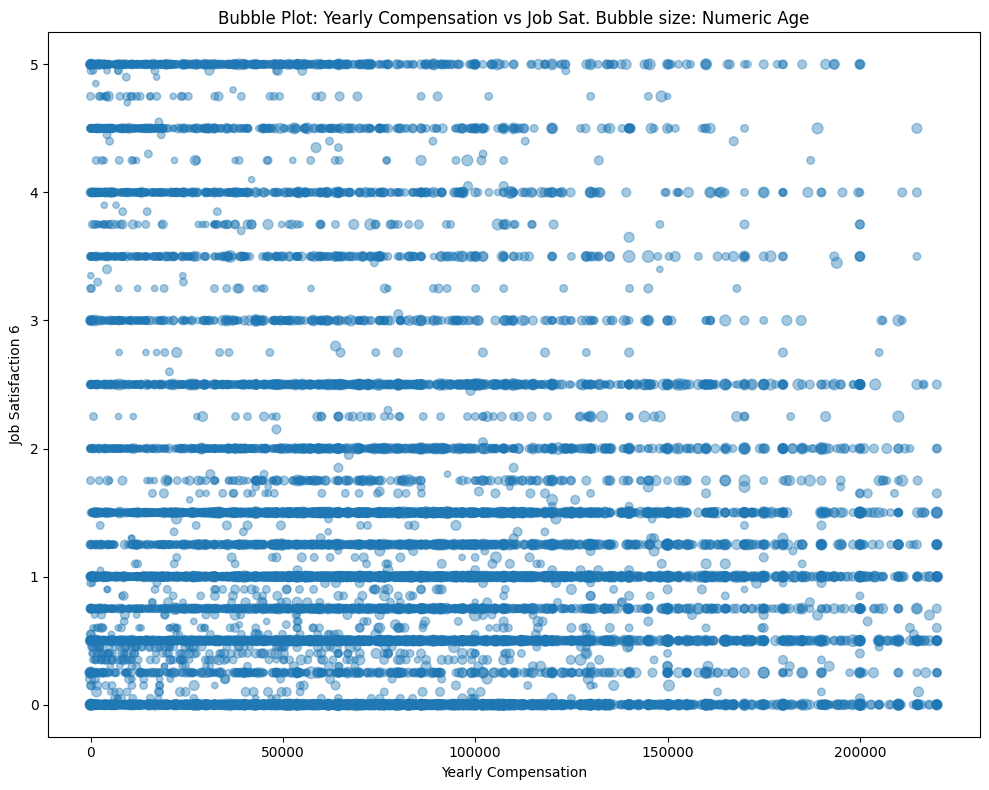

In [10]:
## Write your code here
df_bubble = clean_comp(df[['Age_numeric', 'ConvertedCompYearly', 'JobSatPoints_6']])
df_bubble['JobSatPoints_6'] = df_bubble['JobSatPoints_6'] / 20

plt.figure(figsize=(10, 8))

plt.scatter(df_bubble['ConvertedCompYearly'],
            df_bubble['JobSatPoints_6'],
            s=df_bubble['Age_numeric'],
            alpha=0.4)

plt.title('Bubble Plot: Yearly Compensation vs Job Sat. Bubble size: Numeric Age')
plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction 6')
plt.tight_layout()
plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



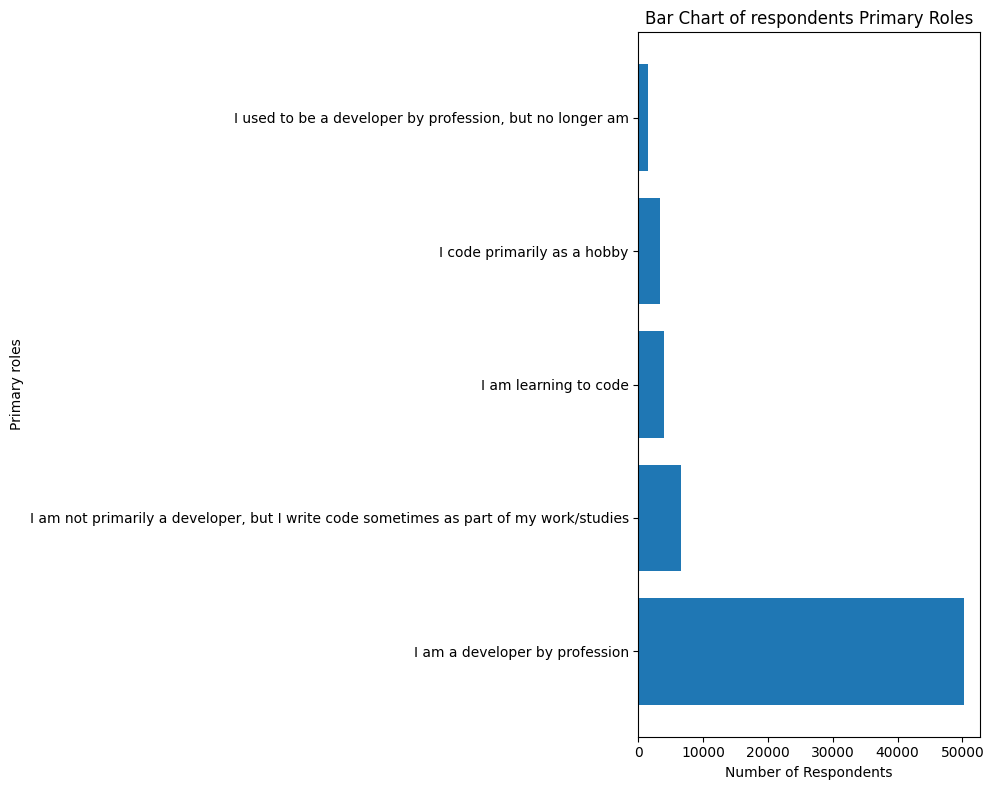

In [11]:
## Write your code here
pri_role = df['MainBranch'].value_counts()

plt.figure(figsize=(10, 8))
plt.barh(pri_role.index, pri_role.values)

plt.title('Bar Chart of respondents Primary Roles')
plt.xlabel('Number of Respondents')
plt.ylabel('Primary roles')
plt.tight_layout()
plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



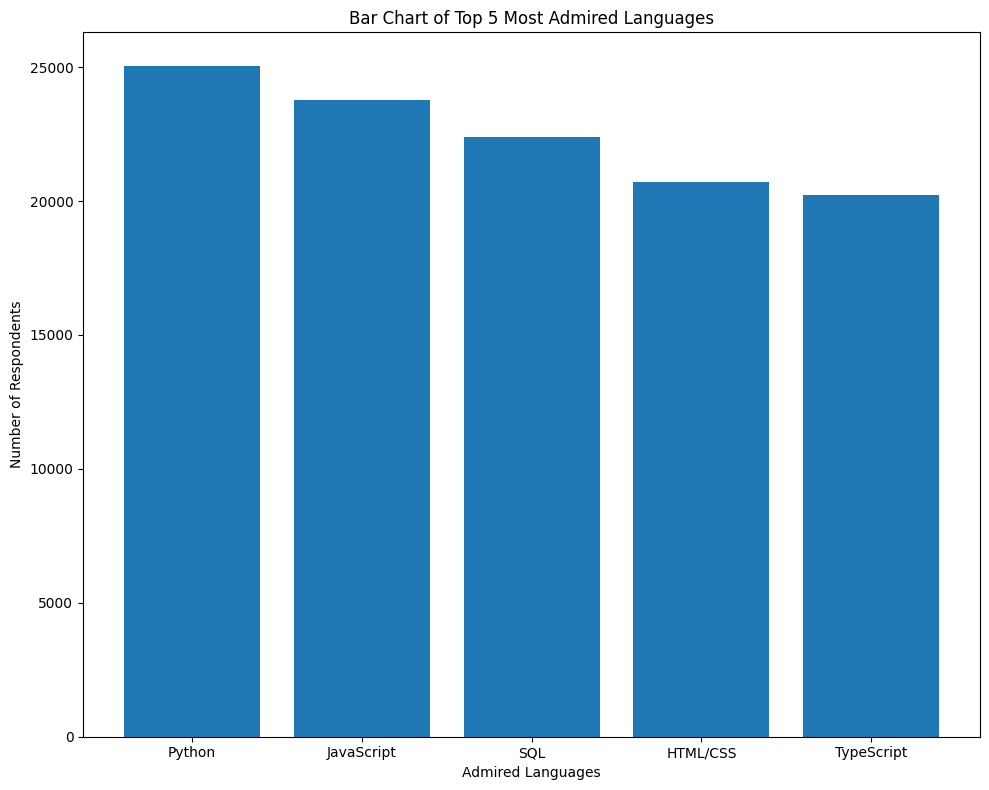

In [27]:
## Write your code here
lang = explode_multiselect(df, 'LanguageWantToWorkWith')
lang_count = lang['LanguageWantToWorkWith'].value_counts().head()

plt.figure(figsize=(10, 8))

plt.bar(lang_count.index, lang_count.values)
plt.title('Bar Chart of Top 5 Most Admired Languages')
plt.ylabel('Number of Respondents')
plt.xlabel('Admired Languages')
plt.tight_layout()
plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


/var/folders/0l/pvtw36_j26v20v1h4xc53l940000gn/T/ipykernel_85773/4219272451.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df.groupby('Age')[cols].median()


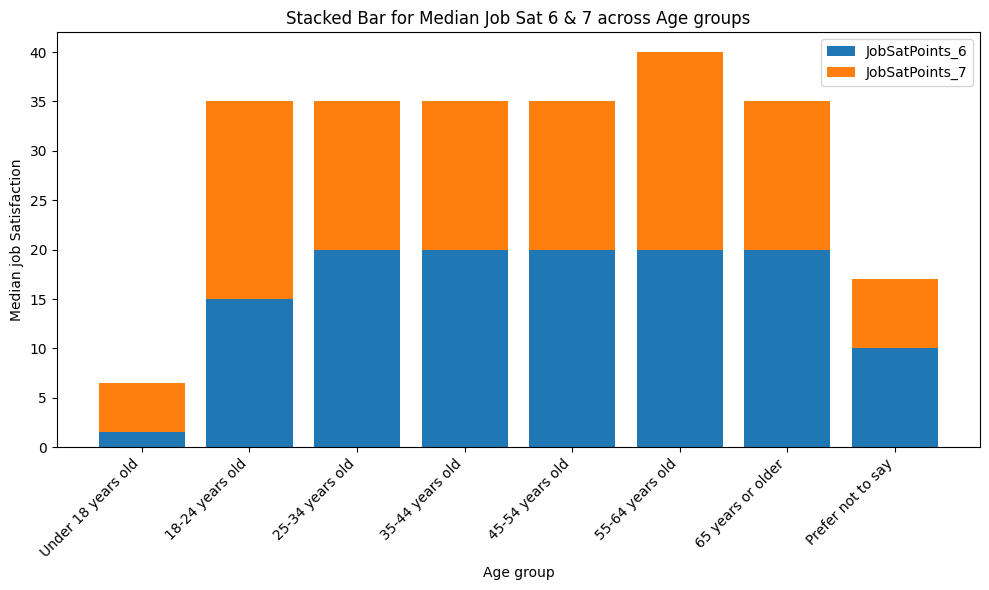

In [28]:
## Write your code here
df_age = order_age(df.copy())
jobsat_by_age = median_by_age(df_age, ['JobSatPoints_6', 'JobSatPoints_7'])

jobsat_by_age = jobsat_by_age.dropna(how='all')

plt.figure(figsize=(10, 6))
x= range(len(jobsat_by_age))

plt.bar(x, jobsat_by_age['JobSatPoints_6'], label='JobSatPoints_6')
# second bar layered on top
plt.bar(x, jobsat_by_age['JobSatPoints_7'], bottom=jobsat_by_age['JobSatPoints_6'], label='JobSatPoints_7')

plt.title('Stacked Bar for Median Job Sat 6 & 7 across Age groups')
plt.xticks(x, jobsat_by_age.index, rotation=45, ha='right')
plt.xlabel('Age group')
plt.ylabel('Median job Satisfaction')
plt.legend()
plt.tight_layout()
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



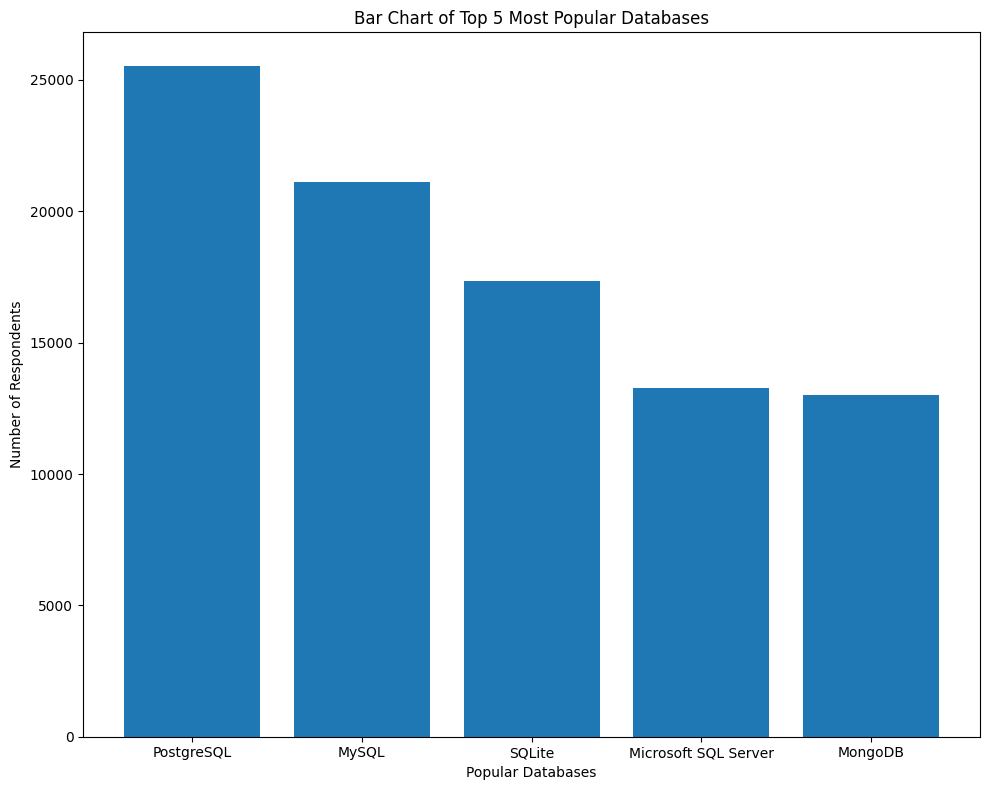

In [29]:
## Write your code here
df_db = explode_multiselect(df, 'DatabaseHaveWorkedWith')
df_db_count = df_db['DatabaseHaveWorkedWith'].value_counts().head()

plt.figure(figsize=(10, 8))

plt.bar(df_db_count.index,df_db_count.values)
plt.title('Bar Chart of Top 5 Most Popular Databases')
plt.ylabel('Number of Respondents')
plt.xlabel('Popular Databases')
plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



/var/folders/0l/pvtw36_j26v20v1h4xc53l940000gn/T/ipykernel_85773/1887870144.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_comp_age = df_clean_comp.groupby('Age')['ConvertedCompYearly'].median()
/var/folders/0l/pvtw36_j26v20v1h4xc53l940000gn/T/ipykernel_85773/1887870144.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


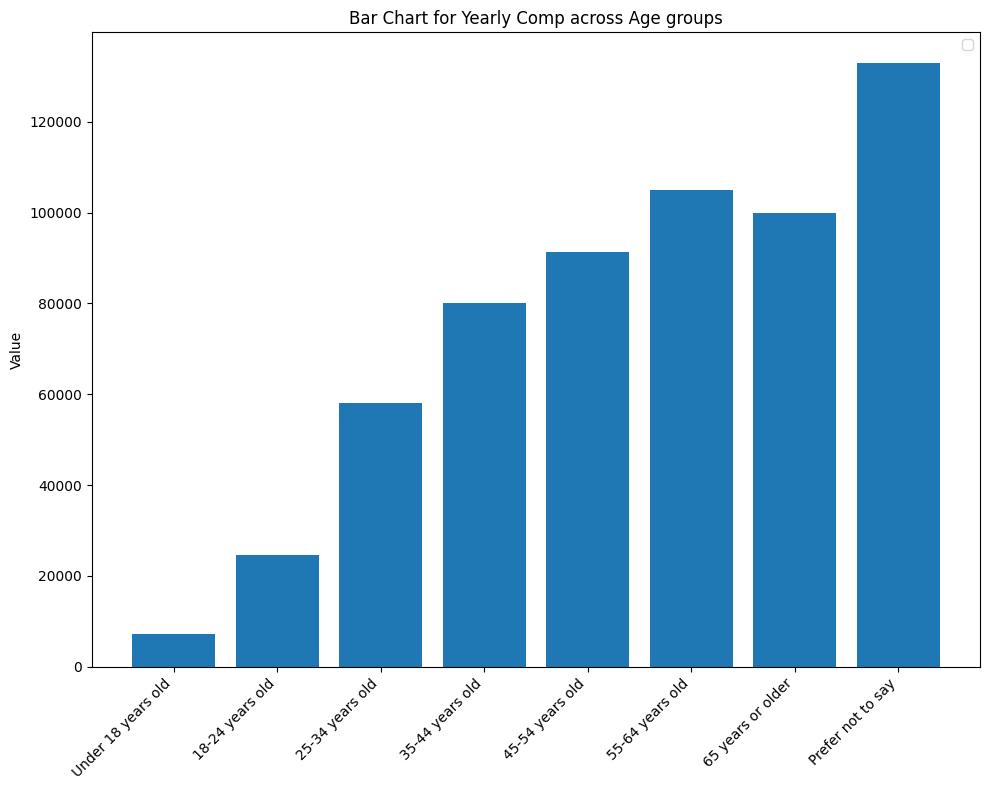

In [34]:
## Write your code here
df_clean_comp = clean_comp(order_age(df.copy()))

median_comp_age = df_clean_comp.groupby('Age')['ConvertedCompYearly'].median()

#Align series to age order
median_comp_age = median_comp_age.loc[age_order]

# remove NaN values for both
valid = ~(median_comp_age.isna())
median_comp_age = median_comp_age[valid]

plt.figure(figsize=(10, 8))
x = range(len(median_comp_age))

plt.bar(x, median_comp_age)

plt.title('Bar Chart for Yearly Comp across Age groups')
plt.xticks(x, median_comp_age.index, rotation=45, ha='right')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show() # Not a gre

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



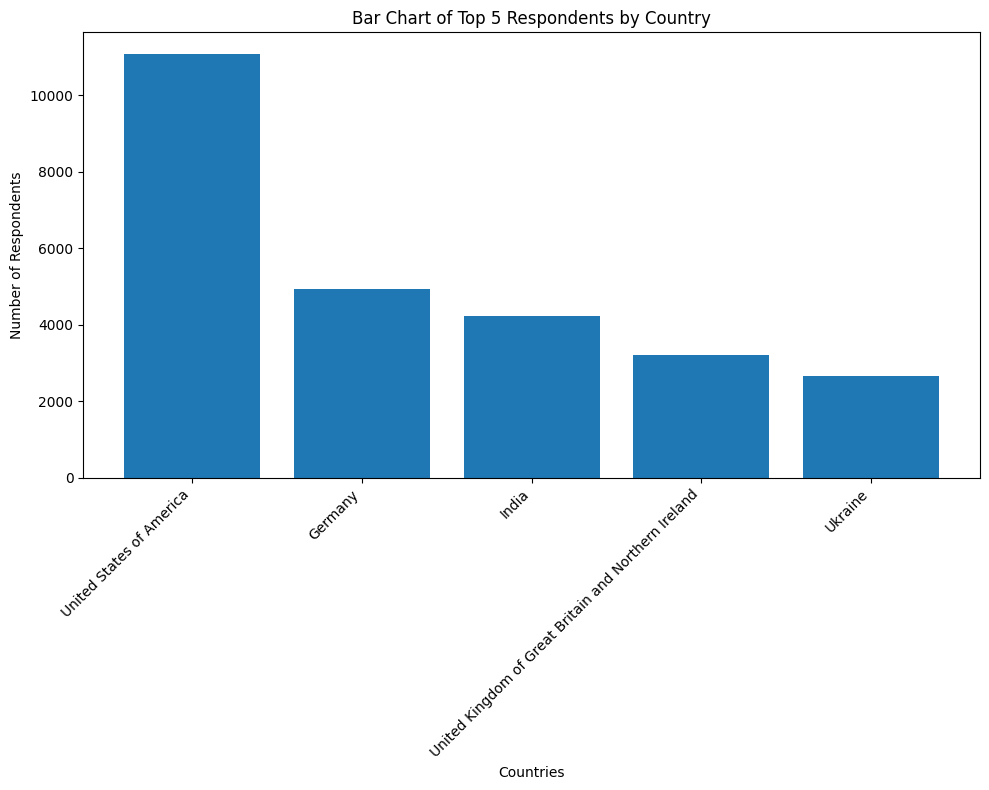

In [36]:
## Write your code here
df_country = explode_multiselect(df, 'Country')
df_ccountry = df_country['Country'].value_counts().head()

plt.figure(figsize=(10, 8))

plt.bar(df_ccountry.index,df_ccountry.values)
plt.title('Bar Chart of Top 5 Respondents by Country')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Countries')
plt.tight_layout()
plt.show()

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
